# Assignment 2: Milestone I Natural Language Processing
## Task 2&3
#### Student Name: XXXX XXXX
#### Student ID: 000000


Environment: Python 3 and Jupyter notebook

Libraries used: please include all the libraries you used in your assignment, e.g.,:
* pandas
* re
* numpy

## Introduction
You should give a brief information of this assessment task here.

<span style="color: red"> Note that this is a sample notebook only. You will need to fill in the proper markdown and code blocks. You might also want to make necessary changes to the structure to meet your own needs. Note also that any generic comments written in this notebook are to be removed and replace with your own words.</span>

## Install fasttest used for vector embedding

In [3]:
!pip install --upgrade pip setuptools wheel
!pip install fasttext-wheel


   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/1.8 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/1.8 MB ? eta -:--:--
   ----------- ---------------------------- 0.5/1.8 MB 837.5 kB/s eta 0:00:02
   ----------------- ---------------------- 0.8/1.8 MB 985.5 kB/s eta 0:00:01
   ----------------------- ---------------- 1.0/1.8 MB 1.0 MB/s eta 0:00:01
   ----------------------------- ---------- 1.3/1.8 MB 1.1 MB/s eta 0:00:01
   ---------------------------------------- 1.8/1.8 MB 1.2 MB/s eta 0:00:00
   ---------------------------------------- 0.0/1.2 MB ? eta -:--:--
   -------- ------------------------------- 0.3/1.2 MB ? eta -:--:--
   ----------------- ---------------------- 0.5/1.2 MB 1.4 MB/s eta 0:00:01
   -------------------------- ------------- 0.8/1.2 MB 1.3 MB/s eta 0:00:01
   ---------------------------------------- 1.2/1.

ERROR: To modify pip, please run the following command:
C:\Users\user\anaconda3\python.exe -m pip install --upgrade pip setuptools wheel


## Importing libraries 

In [453]:
# Code to import libraries as you need in this assessment, e.g.,
import pandas as pd
import ast
from collections import Counter
from gensim.models.fasttext import FastText
import ast
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
import re
from sklearn.feature_extraction.text import CountVectorizer
from textblob import TextBlob
from spellchecker import SpellChecker
from pathlib import Path
from nltk.stem import WordNetLemmatizer



## Task 2. Generating Feature Representations for Clothing Items Reviews

...... Sections and code blocks on buidling different document feature represetations


<span style="color: red"> You might have complex notebook structure in this section, please feel free to create your own notebook structure. </span>

### Load neccessary csv 
processed.csv

In [454]:
# Code to perform the task...
# === Task 2: Bag-of-Words ===

# Load processed.csv (must contain column 'tokens' from Task 1)
df = pd.read_csv("processed.csv")

# Convert 'tokens' from string to list if needed
print("[OK] processed.csv loaded. Rows:", len(df))

[OK] processed.csv loaded. Rows: 19662


### Building the Vocabulary Dictionary

reading the vocabulary.txt file and building a dictionary that maps each word to its index.

In [455]:
# === Task 2: Bag-of-Words ===
word2idx = {}
with open("vocabulary.txt", "r", encoding="utf-8") as f:
    for line in f:
        s = line.strip()
        if not s:
            continue
        w, sidx = s.rsplit(":", 1)
        word2idx[w] = int(sidx)

print("vocabulary.txt loaded. Size:", len(word2idx))
print("Sample entries:", list(word2idx.items())[:5])

vocabulary.txt loaded. Size: 7529
Sample entries: [('a-cup', 0), ('a-flutter', 1), ('a-frame', 2), ('a-kind', 3), ('a-line', 4)]


### Saving outputs
Save the count vector representation as per spectification.
- count_vectors.txt

In [456]:
# code to save output data...
# === Task 2: Bag-of-Words ===
from collections import Counter

out_path = "count_vectors.txt"

with open(out_path, "w", encoding="utf-8") as fout:
    for review_index, tokens in enumerate(df["tokens"].values):
        ctr = Counter()
        tokens = ast.literal_eval(tokens)
        for t in tokens:
            idx = word2idx.get(t)
            if idx is not None:
                ctr[idx] += 1

        # Format: "#<review_index>,idx:count,idx:count,..."
        
        parts = [f"{i}:{ctr[i]}" for i in sorted(ctr)]
        fout.write(f"#{review_index},{','.join(parts)}\n")

print(f"[OK] Wrote {len(df)} lines to {out_path}")
with open(out_path, "r", encoding="utf-8") as f:
    for _ in range(3):
        print(f.readline().rstrip())

[OK] Wrote 19662 lines to count_vectors.txt
#0,686:1,1027:1,1715:1,1791:1,2288:1,2481:1,2602:1,2892:2,3010:1,3087:1,3193:1,3258:1,3549:2,3552:1,3832:1,3934:1,4224:2,4234:1,4427:1,4639:2,5260:1,5668:1,6726:1,7092:1,7207:1,7406:1,7520:1,7522:1
#1,1286:1,2283:1,2502:1,2667:1,3403:1,6739:1
#2,86:1,924:1,1987:1,2646:1,3584:1,3595:1,4506:1,5736:2,5924:1,6716:1


### Extract the feature vector for each review
#### Unweigted Fasttext model

##### Print out dataframe tokens column's type

In [457]:
print(type(df['tokens'].iloc[0]))

<class 'str'>


##### Create a corpus file  
The corpus file represents distinct words of tokens, which will be used in the following steps.

In [458]:
with open("corpus.txt", "w", encoding="utf-8") as f:
    for tokens_str in df['tokens']:
        tokens_list = ast.literal_eval(tokens_str)
        f.write(" ".join(tokens_list) + "\n")

Now we train the skipgram fasttext model based on the corpus file

In [459]:
model = FastText(
    vector_size=100,
    window=5,
    min_count=1,
    min_n=2,      # smallest ngram
    max_n=6,      # largest ngram
    sg=1          # 1=skipgram, 0=CBOW
)
model.build_vocab(corpus_file="corpus.txt")
model.train("corpus.txt", epochs=model.epochs, total_examples=model.corpus_count, total_words=model.corpus_total_words)

(0, 50)

In [460]:
# Create a new column with sentence strings
df["Processed Review"] = df["tokens"].apply(lambda tokens_str: " ".join(ast.literal_eval(tokens_str)))
df["Processed Review"]

0        high hopes wanted work initially petite usual ...
1            jumpsuit fun flirty fabulous time compliments
2        shirt due adjustable front tie length leggings...
3        tracy reese dresses petite feet tall brand pre...
4        basket hte person store pick teh pale hte gorg...
                               ...                        
19657                 happy snag price easy slip cut combo
19658    reminds maternity clothes stretchy shiny mater...
19659                       worked glad store order online
19660    wedding summer medium fits waist perfectly lon...
19661    lovely feminine fits perfectly easy comfy high...
Name: Processed Review, Length: 19662, dtype: object

Try to print out sentence vector of one line to see the format

Save the result to a column

In [461]:
def get_review_vector(tokens, lang_model):
    words = ast.literal_eval(tokens)
    # keep only words in model's vocab
    word_vecs = [lang_model.wv[word] for word in words if word in lang_model.wv]
    return np.sum(word_vecs, axis=0) if word_vecs else np.zeros(lang_model.vector_size)

# Apply to DataFrame
df["unweighted_vector"] = df["tokens"].apply(get_review_vector, lang_model=model)

df["unweighted_vector"].head()

0    [-0.004582084, 0.008442111, 0.003375636, 0.005...
1    [0.009582471, -0.0028617699, 0.00023771054, -0...
2    [0.0037435868, 0.0024244024, -0.0085818, -0.00...
3    [0.0015656227, 0.0061151218, -0.00015065924, 0...
4    [-0.018662449, 0.01308456, 0.007018183, 0.0009...
Name: unweighted_vector, dtype: object

Save to a txt file with correct format

In [462]:
out_path = "unweighted_vectors.txt"

lines = []
for review_index, vec in enumerate(df["unweighted_vector"].values):
    if hasattr(vec, "tolist"):
        vec = vec.tolist()
    lines.append(f"#{review_index},{','.join(map(str, vec))}\n")

with open(out_path, "w", encoding="utf-8") as fout:
    fout.writelines(lines)

print(f"[OK] Wrote {len(lines)} lines to {out_path}")


[OK] Wrote 19662 lines to unweighted_vectors.txt


Reload the corpus for TF-IDF fit transformation

In [463]:
from sklearn.feature_extraction.text import TfidfVectorizer
with open("vocabulary.txt", "r", encoding="utf-8") as f:
    vocab = {}
    for line in f:
        s = line.strip()
        if not s:
            continue
        w, sidx = s.rsplit(":", 1)
        vocab[w] = int(sidx)

joined_reviews = df["Processed Review"].values.tolist()

tVectorizer = TfidfVectorizer(analyzer = "word",vocabulary = vocab, norm='l2') # initialised the TfidfVectorizer
tfidf_features = tVectorizer.fit_transform(joined_reviews) # generate the tfidf vector representation for all articles

In [464]:

import numpy as np
from gensim.corpora import Dictionary
from gensim.models import TfidfModel
from gensim.matutils import sparse2full


import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer

def get_tfidf_weighted_embeddings(tfidf_features, feature_names, embedding_dim, lang_model_dict):
    """
    Compute sentence embeddings by weighting word embeddings with TF-IDF scores.

    Parameters:
    - tfidf_features: sparse TF-IDF matrix from TfidfVectorizer
    - feature_names: vocabulary list (tVectorizer.get_feature_names_out())
    - embedding_dim: dimension of embeddings (e.g., 100 for GloVe 100d)
    - lang_model_dict: dictionary {word: vector} (e.g., GloVe embeddings)

    Returns:
    - doc_vectors: numpy array of shape (n_docs, embedding_dim)
    """
    n_docs = tfidf_features.shape[0]
    doc_vectors = np.zeros((n_docs, embedding_dim))

    for i in range(n_docs):
        row = tfidf_features[i]
        weighted_sum = np.zeros(embedding_dim, dtype=np.float32)
        for idx, weight in zip(row.indices, row.data):
            word = feature_names[idx]
            if word in lang_model_dict:
                vec = lang_model_dict[word]
                weighted_sum += vec * weight

        doc_vectors[i] = weighted_sum

    return doc_vectors


In [465]:
doc_vectors = get_tfidf_weighted_embeddings(tfidf_features, tVectorizer.get_feature_names_out(), embedding_dim=model.vector_size, lang_model_dict=model.wv)
doc_vectors

array([[-4.55795816e-05,  1.11624808e-03,  5.99447521e-04, ...,
         8.77632061e-04, -9.36767537e-06, -2.05756471e-04],
       [ 4.03723400e-03, -1.27495453e-03,  5.55218663e-04, ...,
        -1.47394161e-03,  3.14088131e-04, -7.83965457e-04],
       [ 7.68642290e-04,  8.19423120e-04, -2.31320807e-03, ...,
         7.77299632e-04,  1.69847033e-03,  9.61551559e-04],
       ...,
       [ 2.18119426e-03,  4.76487709e-04, -1.32942013e-03, ...,
         1.98589452e-03, -1.07304356e-03, -2.20395555e-03],
       [ 2.68219766e-04, -1.46086642e-03, -1.06116396e-03, ...,
         1.34442496e-04, -8.75275291e-04, -3.89812340e-04],
       [-7.42801232e-04,  6.74776384e-05,  1.01477245e-03, ...,
        -2.27010067e-04, -8.95694131e-04, -7.84254982e-04]])

Use TF-IDF weight to vectorize the tokens

Save the result

In [466]:
df["weighted_vector"] = [row.data for row in doc_vectors]         # corresponding weights
df["weighted_vector"].head()

0    [-4.5579581637866795e-05, 0.001116248080506920...
1    [0.004037234000861645, -0.0012749545276165009,...
2    [0.0007686422904953361, 0.0008194231195375323,...
3    [0.00018800361431203783, 0.0008736902382224798...
4    [-0.003316394053399563, 0.0021922062151134014,...
Name: weighted_vector, dtype: object

In [467]:
df.head()

,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name,tokens,Processed Review,unweighted_vector,weighted_vector
0,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses,"['high', 'hopes', 'wanted', 'work', 'initially...",high hopes wanted work initially petite usual ...,"[-0.004582084, 0.008442111, 0.003375636, 0.005...","[-4.5579581637866795e-05, 0.001116248080506920..."
1,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants,"['jumpsuit', 'fun', 'flirty', 'fabulous', 'tim...",jumpsuit fun flirty fabulous time compliments,"[0.009582471, -0.0028617699, 0.00023771054, -0...","[0.004037234000861645, -0.0012749545276165009,..."
2,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses,"['shirt', 'due', 'adjustable', 'front', 'tie',...",shirt due adjustable front tie length leggings...,"[0.0037435868, 0.0024244024, -0.0085818, -0.00...","[0.0007686422904953361, 0.0008194231195375323,..."
3,1080,49,Not for the very petite,"I love tracy reese dresses, but this one is no...",2,0,4,General,Dresses,Dresses,"['tracy', 'reese', 'dresses', 'petite', 'feet'...",tracy reese dresses petite feet tall brand pre...,"[0.0015656227, 0.0061151218, -0.00015065924, 0...","[0.00018800361431203783, 0.0008736902382224798..."
4,858,39,Cagrcoal shimmer fun,I aded this in my basket at hte last mintue to...,5,1,1,General Petite,Tops,Knits,"['basket', 'hte', 'person', 'store', 'pick', '...",basket hte person store pick teh pale hte gorg...,"[-0.018662449, 0.01308456, 0.007018183, 0.0009...","[-0.003316394053399563, 0.0021922062151134014,..."


In [468]:
out_path = "weighted_vectors.txt"

with open(out_path, "w", encoding="utf-8") as fout:
    for review_index, vec_str in enumerate(df["weighted_vector"].values):
        # Convert string "[0.1, 0.2, ...]" into Python list
        fout.write(f"#{review_index}," + ",".join(map(str, vec_str)) + "\n")

print(f"[OK] Wrote {len(df)} lines to {out_path}")

# Preview first 3 lines
with open(out_path, "r", encoding="utf-8") as f:
    for _ in range(3):
        print(f.readline().rstrip())

[OK] Wrote 19662 lines to weighted_vectors.txt
#0,-4.5579581637866795e-05,0.0011162480805069208,0.0005994475213810802,0.0009685225086286664,7.156882202252746e-05,-0.0017260927706956863,0.0006833639927208424,0.0014264440396800637,-0.0004056963953189552,0.00019524515664670616,0.00019494167645461857,-0.0025116954930126667,-0.0020033069886267185,-0.0009458493441343307,0.00011963455472141504,0.0009065368794836104,0.000659095705486834,-0.0019269241020083427,0.0002333549491595477,0.0003023771569132805,-0.00027364224661141634,-0.0002876344951801002,-0.002575063146650791,0.0005880070384591818,0.0014150639763101935,-0.00012751444592140615,0.0014180453727021813,0.0005673483246937394,-0.0015121186152100563,-0.0014089879114180803,0.0030321727972477674,0.0027162579353898764,-0.0029752289410680532,0.0008275426807813346,-5.162041270523332e-05,0.00017477202345617115,0.0007311549270525575,-0.0014539938420057297,0.0003617190814111382,0.0013348221546038985,0.0011626668274402618,-0.0005095306551083922,0.00

## Task 3. Clothing Review Classification

...... Sections and code blocks on buidling classification models based on different document feature represetations. 
Detailed comparsions and evaluations on different models to answer each question as per specification. 

<span style="color: red"> You might have complex notebook structure in this section, please feel free to create your own notebook structure. </span>

In [469]:
# Code to perform the task...
def load_vectors(file_path, sparse=False):
    vectors = []
    with open(file_path, "r", encoding="utf-8") as f:
        for line in f:
            parts = line.strip().split(",", 1)
            if len(parts) < 2:
                continue
            vec_str = parts[1]
            if sparse:
                vec = {}
                for item in vec_str.split(","):
                    if ":" in item:
                        idx, val = item.split(":")
                        vec[int(idx)] = int(val)
                vectors.append(vec)
            else:
                vec_str = vec_str.strip("[]")
                vec = np.array([float(x) for x in vec_str.split(",")])
                vectors.append(vec)
    return vectors


In [470]:
from sklearn.preprocessing import StandardScaler


X_count     = load_vectors("count_vectors.txt", sparse=True)
X_ft_unweighted = StandardScaler().fit_transform(df['unweighted_vector'].values.tolist())
X_ft_weighted   = StandardScaler().fit_transform(df['weighted_vector'].values.tolist())

In [471]:
X_ft_unweighted

array([[-0.41008267,  1.13857588,  1.08171439, ...,  0.32419656,
        -0.74554466,  0.12561365],
       [ 2.08277704, -0.86880132,  0.56293228, ..., -0.84811328,
        -0.08418903, -0.34295922],
       [ 1.05517543,  0.06993304, -0.89516626, ...,  0.25754058,
         1.23782164,  0.90618343],
       ...,
       [ 1.22509231, -0.24020431,  0.04366012, ...,  0.47169759,
        -0.58828707, -0.72017763],
       [ 0.3862653 , -1.25162738, -0.19706609, ..., -0.36155919,
        -0.99985756, -0.61875862],
       [ 0.08988366, -0.33315996,  0.90726523, ..., -0.29544823,
        -0.61947888, -0.35623743]])

In [472]:
y = df["Recommended IND"].values  

In [473]:
df["Recommended IND"].value_counts()

Recommended IND
1    16087
0     3575
Name: count, dtype: int64

In [474]:
from sklearn.feature_extraction import DictVectorizer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def run_model_analysis(X_count, X_unweighted, X_weighted, y, num_folds=10, seed=42):
    kf = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=seed)

    for name, X in [("Count", X_count), ("Unweighted", X_unweighted), ("Weighted", X_weighted)]:
        # Handle Count dicts with DictVectorizer
        if name == "Count":
            vec = DictVectorizer(sparse=True)
            X = vec.fit_transform(X)

        print(f"\n=== Using {name} Vectors ===")

        acc_scores, f1_scores = [], []

        all_preds, all_true = [], []

        for train_idx, test_idx in kf.split(X, y):
            X_train, X_test = X[train_idx], X[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]

            weights = {0: 3.0, 1: 1.0}  # Class 0 has quadruple the importance
            model = LogisticRegression(max_iter=1000, random_state=seed, class_weight=weights)
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)

            # Store scores
            acc_scores.append(accuracy_score(y_test, y_pred))
            f1_scores.append(f1_score(y_test, y_pred, average="weighted"))

            # Save predictions for confusion matrix later
            all_preds.extend(y_pred)
            all_true.extend(y_test)

        # Average results
        acc = np.mean(acc_scores)
        f1 = np.mean(f1_scores)
        print(f"Average Accuracy: {acc:.3f}")
        print(f"Average F1 Score: {f1:.3f}")

        # Detailed classification report
        print("\nClassification Report (Aggregated):")
        print(classification_report(all_true, all_preds, digits=3))

        # Confusion matrix
        cm = confusion_matrix(all_true, all_preds)
        print("Confusion Matrix:")
        print(cm)

        # --- Plot confusion matrix ---
        plt.figure(figsize=(5, 4))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                    xticklabels=["Not Recommended", "Recommended"],
                    yticklabels=["Not Recommended", "Recommended"])
        plt.xlabel("Predicted")
        plt.ylabel("True")
        plt.title(f"Confusion Matrix ({name} Vectors)")
        plt.show()



=== Using Count Vectors ===
Average Accuracy: 0.863
Average F1 Score: 0.866

Classification Report (Aggregated):
              precision    recall  f1-score   support

           0      0.607     0.693     0.647      3575
           1      0.929     0.900     0.915     16087

    accuracy                          0.863     19662
   macro avg      0.768     0.797     0.781     19662
weighted avg      0.871     0.863     0.866     19662

Confusion Matrix:
[[ 2476  1099]
 [ 1601 14486]]


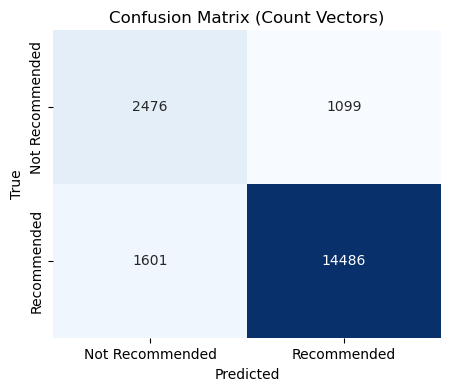


=== Using Unweighted Vectors ===
Average Accuracy: 0.765
Average F1 Score: 0.774

Classification Report (Aggregated):
              precision    recall  f1-score   support

           0      0.380     0.464     0.418      3575
           1      0.875     0.832     0.853     16087

    accuracy                          0.765     19662
   macro avg      0.628     0.648     0.636     19662
weighted avg      0.785     0.765     0.774     19662

Confusion Matrix:
[[ 1660  1915]
 [ 2704 13383]]


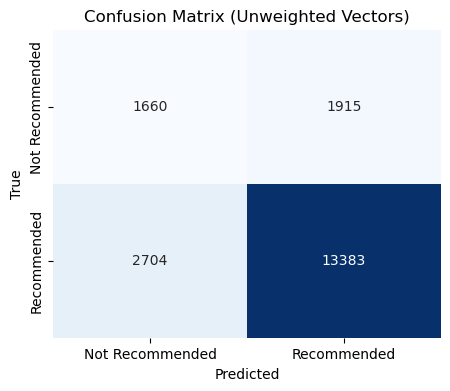


=== Using Weighted Vectors ===
Average Accuracy: 0.747
Average F1 Score: 0.759

Classification Report (Aggregated):
              precision    recall  f1-score   support

           0      0.349     0.451     0.394      3575
           1      0.870     0.813     0.840     16087

    accuracy                          0.747     19662
   macro avg      0.609     0.632     0.617     19662
weighted avg      0.775     0.747     0.759     19662

Confusion Matrix:
[[ 1612  1963]
 [ 3006 13081]]


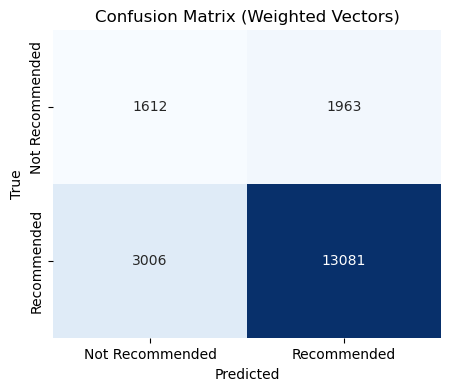

In [475]:
run_model_analysis(X_count, X_ft_unweighted, X_ft_weighted, y, 10, 42)

Try Word2Net

In [476]:
from gensim.models.word2vec import Word2Vec


w2v_model = w2v_model = Word2Vec(
    vector_size=100,   # embedding size
    window=5,          # context window
    min_count=2,       # ignore very rare words
    sg=1,              # 1=Skip-gram, 0=CBOW
    workers=4,         # parallel training
    epochs=10
)
w2v_model.build_vocab(corpus_file="corpus.txt")
w2v_model.train("corpus.txt", epochs=w2v_model.epochs, total_examples=w2v_model.corpus_count, total_words=w2v_model.corpus_total_words)

(0, 100)

In [477]:
w2v_unweighted_data = df["tokens"].apply(get_review_vector, lang_model=w2v_model).values.tolist()

In [478]:
w2v_unweighted_data

[array([ 0.03748136, -0.01911306, -0.01699583,  0.00470572, -0.00206021,
        -0.03742803,  0.05322826,  0.05383411, -0.0669263 , -0.03253038,
        -0.04645388, -0.04433738, -0.00112085,  0.0021545 ,  0.02506023,
        -0.0482174 , -0.00867943, -0.02246797, -0.00175523, -0.03410244,
        -0.00347719,  0.07276551, -0.04072285,  0.00477166,  0.02919676,
         0.06201081, -0.01457852,  0.00496644, -0.01206666,  0.03214224,
        -0.05161417,  0.0471442 , -0.01085626, -0.08826848, -0.03822842,
         0.05910529, -0.08996633, -0.07995676, -0.01742602, -0.05972382,
         0.01673211, -0.01454612, -0.00434304,  0.03296972,  0.01245971,
        -0.04261096, -0.00055021,  0.0124173 ,  0.00111197, -0.05363969,
        -0.06278351, -0.01177771,  0.05760232, -0.04309282, -0.02212508,
        -0.04247205, -0.01919665,  0.00859473, -0.00093332,  0.00286633,
         0.01259296, -0.06350052,  0.00573145, -0.00729943, -0.02917354,
         0.01622691, -0.04592719, -0.02986981,  0.0

In [479]:
# load corpus into sentences for vectorizer
with open("corpus.txt", "r", encoding="utf-8") as f:
    sentences = [line.strip() for line in f]

doc_vectors = get_tfidf_weighted_embeddings(tfidf_features, tVectorizer.get_feature_names_out(), embedding_dim=model.vector_size, lang_model_dict=w2v_model.wv)
w2v_weighted_data = [row.data for row in doc_vectors]  


In [480]:
X_w2v_unweighted = StandardScaler().fit_transform(np.vstack(w2v_unweighted_data))
X_w2v_weighted   = StandardScaler().fit_transform(np.vstack(w2v_weighted_data))



=== Using Count Vectors ===
Average Accuracy: 0.863
Average F1 Score: 0.866

Classification Report (Aggregated):
              precision    recall  f1-score   support

           0      0.607     0.693     0.647      3575
           1      0.929     0.900     0.915     16087

    accuracy                          0.863     19662
   macro avg      0.768     0.797     0.781     19662
weighted avg      0.871     0.863     0.866     19662

Confusion Matrix:
[[ 2476  1099]
 [ 1601 14486]]


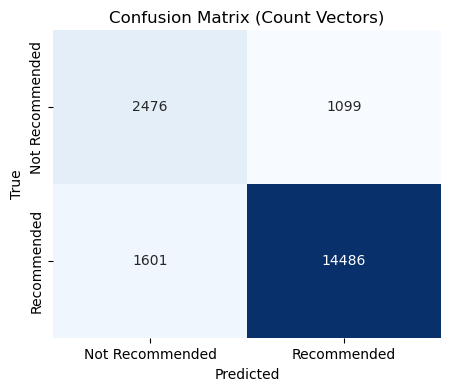


=== Using Unweighted Vectors ===
Average Accuracy: 0.766
Average F1 Score: 0.773

Classification Report (Aggregated):
              precision    recall  f1-score   support

           0      0.377     0.440     0.406      3575
           1      0.871     0.839     0.854     16087

    accuracy                          0.766     19662
   macro avg      0.624     0.639     0.630     19662
weighted avg      0.781     0.766     0.773     19662

Confusion Matrix:
[[ 1572  2003]
 [ 2594 13493]]


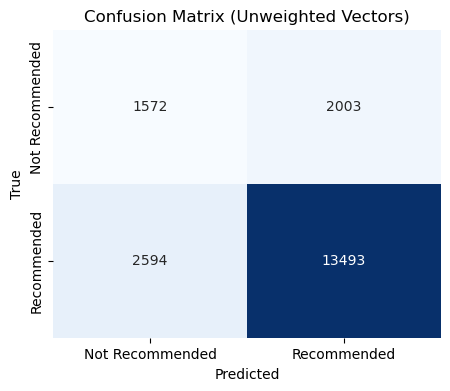


=== Using Weighted Vectors ===
Average Accuracy: 0.750
Average F1 Score: 0.759

Classification Report (Aggregated):
              precision    recall  f1-score   support

           0      0.345     0.417     0.378      3575
           1      0.864     0.824     0.844     16087

    accuracy                          0.750     19662
   macro avg      0.605     0.621     0.611     19662
weighted avg      0.770     0.750     0.759     19662

Confusion Matrix:
[[ 1492  2083]
 [ 2827 13260]]


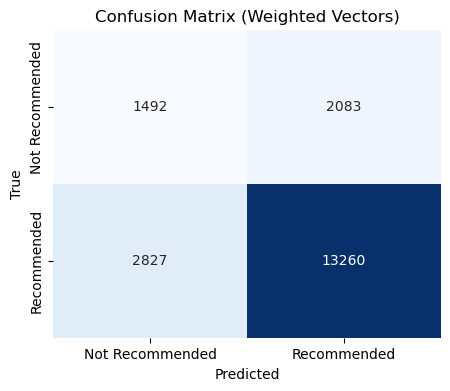

In [481]:
run_model_analysis(X_count, X_w2v_unweighted, X_w2v_weighted, y)

Try Glove

In [482]:
!pip install wget

^C


In [ ]:
import wget
url = "http://nlp.stanford.edu/data/glove.6B.zip"
wget.download(url, "glove.6B.zip")

In [255]:
import zipfile

with zipfile.ZipFile("glove.6B.zip", "r") as zip_ref:
    zip_ref.extractall("glove")

In [484]:
import os
# Path to the GloVe file
path_to_glove_file = os.path.join("glove", "glove.6B.100d.txt")

# Initialize an empty dictionary
glove_wv = {}

# Read the file line by line
with open(path_to_glove_file, encoding="utf-8") as f:
    for line in f:
        word, coefs = line.split(maxsplit=1)   # first token = word, rest = vector
        coefs = np.fromstring(coefs, "f", sep=" ")  # convert to numpy array
        glove_wv[word] = coefs                 # store in dict

print("Found %s word vectors." % len(glove_wv))


Found 400000 word vectors.


In [485]:
def get_review_vector_glove(tokens, embeddings_index, embedding_dim=100):
    vecs = [embeddings_index[word] for word in tokens if word in embeddings_index]
    if not vecs:
        return np.zeros(embedding_dim)
    return np.mean(vecs, axis=0)

In [486]:
glove_unweighted_data = df["tokens"].apply(lambda x: get_review_vector_glove(ast.literal_eval(x), glove_wv, embedding_dim=100)).values.tolist()

In [487]:
glove_unweighted_data

[array([-2.37603962e-01,  1.87611982e-01,  2.06782848e-01, -1.72068402e-01,
         6.61378056e-02,  1.36691332e-02, -2.33567227e-02,  1.40242264e-01,
        -2.55546463e-03,  2.42306277e-01,  1.41616151e-01,  1.25330091e-02,
         1.93498850e-01,  1.08647849e-02,  1.96627885e-01, -4.82560620e-02,
         4.99383407e-03,  3.68231684e-02,  7.15183616e-02, -1.06607646e-01,
         1.03885695e-01,  5.64851873e-02,  1.00387305e-01, -3.86443082e-03,
         2.11305186e-01, -1.03310585e-01, -1.18373983e-01, -3.17010999e-01,
        -2.63772845e-01, -2.59434611e-01,  3.39593329e-02,  2.22990528e-01,
        -8.36506262e-02, -2.30186611e-01,  1.45958006e-01,  1.70477778e-01,
         1.00440197e-02,  6.75151944e-02,  1.63908079e-02, -8.94875526e-02,
         8.85799080e-02, -4.08290982e-01, -3.43823247e-02,  2.66765319e-02,
        -4.74542156e-02,  7.01193810e-02,  1.43701673e-01,  3.43122631e-02,
         2.44205575e-02, -2.67926276e-01, -9.67212580e-03, -1.35283088e-02,
         1.2

In [488]:
# load corpus into sentences for vectorizer
with open("corpus.txt", "r", encoding="utf-8") as f:
    sentences = [line.strip() for line in f]

doc_vectors = get_tfidf_weighted_embeddings(tfidf_features, tVectorizer.get_feature_names_out(), embedding_dim=model.vector_size, lang_model_dict=glove_wv)
glove_weighted_data = [vec.tolist() for vec in doc_vectors]


In [489]:
glove_weighted_data

[[-0.8995571136474609,
  0.8415049314498901,
  1.256264328956604,
  -0.8684297204017639,
  0.5590924620628357,
  0.05768107995390892,
  -0.1970556229352951,
  0.4424719214439392,
  0.16502472758293152,
  0.901776134967804,
  0.815646767616272,
  0.22426331043243408,
  0.9216389060020447,
  -0.008221089839935303,
  1.006370186805725,
  -0.27037906646728516,
  -0.2328013926744461,
  0.33130717277526855,
  0.35539424419403076,
  -0.5641897320747375,
  0.7527492642402649,
  0.29751500487327576,
  0.5001363754272461,
  0.45175760984420776,
  0.7315811514854431,
  -0.6544556021690369,
  -0.4603109061717987,
  -1.1179429292678833,
  -1.1246148347854614,
  -1.4320658445358276,
  0.3607940673828125,
  1.2105276584625244,
  -0.40177014470100403,
  -0.9654479026794434,
  0.6385622620582581,
  0.6866651773452759,
  -0.23411676287651062,
  0.25090378522872925,
  -0.20198994874954224,
  -0.3163881003856659,
  0.5134254097938538,
  -1.595304250717163,
  -0.2012922465801239,
  0.2264261394739151,
  -0

In [490]:
X_glove_unweighted = StandardScaler().fit_transform(np.vstack(glove_unweighted_data))
X_glove_weighted   = StandardScaler().fit_transform(np.vstack(glove_weighted_data))



=== Using Count Vectors ===
Average Accuracy: 0.863
Average F1 Score: 0.866

Classification Report (Aggregated):
              precision    recall  f1-score   support

           0      0.607     0.693     0.647      3575
           1      0.929     0.900     0.915     16087

    accuracy                          0.863     19662
   macro avg      0.768     0.797     0.781     19662
weighted avg      0.871     0.863     0.866     19662

Confusion Matrix:
[[ 2476  1099]
 [ 1601 14486]]


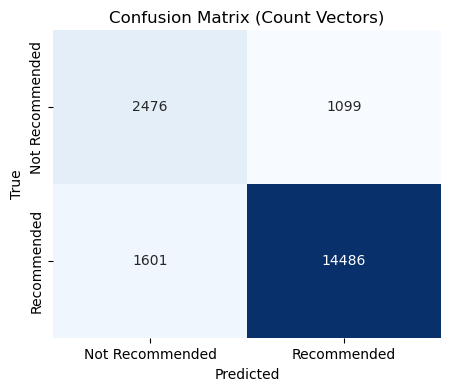


=== Using Unweighted Vectors ===
Average Accuracy: 0.801
Average F1 Score: 0.813

Classification Report (Aggregated):
              precision    recall  f1-score   support

           0      0.466     0.638     0.539      3575
           1      0.912     0.838     0.874     16087

    accuracy                          0.801     19662
   macro avg      0.689     0.738     0.706     19662
weighted avg      0.831     0.801     0.813     19662

Confusion Matrix:
[[ 2281  1294]
 [ 2609 13478]]


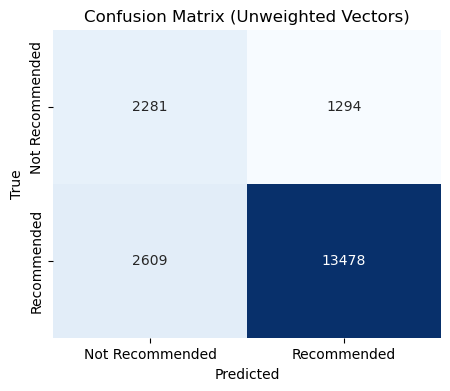


=== Using Weighted Vectors ===
Average Accuracy: 0.793
Average F1 Score: 0.806

Classification Report (Aggregated):
              precision    recall  f1-score   support

           0      0.451     0.628     0.525      3575
           1      0.909     0.830     0.868     16087

    accuracy                          0.793     19662
   macro avg      0.680     0.729     0.696     19662
weighted avg      0.826     0.793     0.806     19662

Confusion Matrix:
[[ 2244  1331]
 [ 2732 13355]]


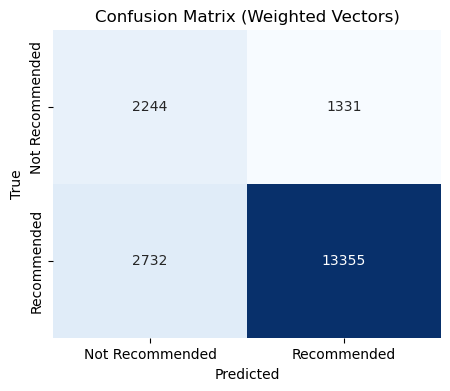

In [491]:
run_model_analysis(X_count, X_glove_unweighted, X_glove_weighted, y)

### Q2: Does more information provide higher accuracy?  
#### Title only data

In [525]:
from nltk.tokenize import RegexpTokenizer

df = pd.read_csv('processed.csv')
# 2/3/4. Tokenizing clothing review

# define tokenizer
tokenizer = RegexpTokenizer(r"[a-zA-Z]+(?:[-'][a-zA-Z]+)?")

# Tokenize the review text + lowercasing and removing words with length < 2
df["title_tokens"] = (
    df["Title"]
      .fillna("") # replace NaN with empty string
      .astype(str)
      .apply(lambda text: [token.lower() for token in tokenizer.tokenize(text) if len(token) > 1])
)

df["title_tokens"]

0                             [some, major, design, flaws]
1                                      [my, favorite, buy]
2                                      [flattering, shirt]
3                            [not, for, the, very, petite]
4                                 [cagrcoal, shimmer, fun]
                               ...                        
19657                 [great, dress, for, many, occasions]
19658                    [wish, it, was, made, of, cotton]
19659                            [cute, but, see, through]
19660    [very, cute, dress, perfect, for, summer, part...
19661                [please, make, more, like, this, one]
Name: title_tokens, Length: 19662, dtype: object

In [526]:
def preprocess_data(tokens: pd.Series):
    # --- Step 1: Clean tokens ---
    def clean_tokens(tokens):
        if not isinstance(tokens, list):
            return []
        return [str(t).lower() for t in tokens if t is not None]

    tokens = tokens.apply(clean_tokens)

    # --- Step 2: Spell correction (optional, heavy) ---
    spell = SpellChecker()
    def correct_tokens(tokens):
        corrected = []
        for word in tokens:
            if word in spell.unknown([word]):
                suggestion = spell.correction(word)
                corrected.append(suggestion if suggestion else word)
            else:
                corrected.append(word)
        return corrected
    tokens = tokens.apply(correct_tokens)

    # --- Step 3: Remove stopwords ---
    stop_path = Path("stopwords_en.txt")
    with open(stop_path, "r", encoding="utf-8") as f:
        stop_words = {line.strip() for line in f if line.strip()}

    def remove_stopwords(tokens, stopset):
        return [t for t in tokens if t not in stopset]

    tokens = tokens.apply(remove_stopwords, stopset=stop_words)

    # --- Step 4: Remove rare words (appear only once globally) ---
    term_freq = pd.Series(np.concatenate(tokens.values)).value_counts()
    tokens = tokens.apply(lambda toks: [t for t in toks if term_freq[t] > 1])

    # --- Step 5: Remove top 20 most frequent words by doc frequency ---
    doc_freq = Counter()
    for toks in tokens:
        doc_freq.update(set(toks))

    top_20_words = {word for word, _ in doc_freq.most_common(20)}
    tokens = tokens.apply(lambda toks: [w for w in toks if w not in top_20_words])

    # --- Step 6: Lemmatization ---
    lemmatizer = WordNetLemmatizer()
    tokens = tokens.apply(lambda toks: [lemmatizer.lemmatize(w) for w in toks])

    # --- Step 7: Final cleanup ---
    def clean_vocab_token(token):
        token = token.lower().strip()
        if re.fullmatch(r"[a-z0-9]+", token) and len(token) > 2:
            return token
        return None

    tokens = tokens.apply(
        lambda toks: [clean_vocab_token(t) for t in toks if clean_vocab_token(t)]
    )

    return tokens


# --- Apply preprocessing to Title ---
df["title_tokens"] = preprocess_data(df["title_tokens"])
df["title_tokens"]

0        [major, design, flaw]
1              [favorite, buy]
2                           []
3                     [petite]
4               [shimmer, fun]
                 ...          
19657               [occasion]
19658           [made, cotton]
19659                       []
19660                       []
19661                   [make]
Name: title_tokens, Length: 19662, dtype: object

In [527]:
# Bag-of-Words for Title
def embed_data(tokens, type='title'):
    out_path = f"{type}_count_vectors.txt"

    with open(out_path, "w", encoding="utf-8") as fout:
        for review_index, ts in enumerate(tokens.values):
            ctr = Counter()
            for t in ts:
                idx = word2idx.get(t)
                if idx is not None:
                    ctr[idx] += 1

            # Format: "#<review_index>,idx:count,idx:count,..."
            
            parts = [f"{i}:{ctr[i]}" for i in sorted(ctr)]
            fout.write(f"#{review_index},{','.join(parts)}\n")

    with open(f"{type}_corpus.txt", "w", encoding="utf-8") as f:
        for tokens_str in tokens:
            f.write(" ".join(tokens_str) + "\n")

    model = FastText(
        vector_size=100,
        window=5,
        min_count=1,
        min_n=2,      # smallest ngram
        max_n=6,      # largest ngram
        sg=1          # 1=skipgram, 0=CBOW
    )
    model.build_vocab(corpus_file=f"{type}_corpus.txt")
    model.train(f"{type}_corpus.txt", epochs=model.epochs, total_examples=model.corpus_count, total_words=model.corpus_total_words)

    # Create a new column with sentence strings
    processed_review = tokens.apply(lambda tokens_str: " ".join(tokens_str))
    unweigted_vector = tokens.apply(lambda x: get_review_vector_glove(x, glove_wv, embedding_dim=100)).values.tolist()
    
    joined_reviews = processed_review.values.tolist()
    tVectorizer = TfidfVectorizer(analyzer = "word",vocabulary = vocab, norm='l2') # initialised the TfidfVectorizer
    tfidf_features = tVectorizer.fit_transform(joined_reviews) # generate the tfidf vector representation for all articles
    doc_vectors = get_tfidf_weighted_embeddings(tfidf_features, tVectorizer.get_feature_names_out(), embedding_dim=model.vector_size, lang_model_dict=glove_wv)
    weighted_data = [vec.tolist() for vec in doc_vectors]
    
    return unweigted_vector, weighted_data
    
    


In [528]:
title_unweighted, title_weighted = embed_data(df["title_tokens"], type='title')
title_count_vectors = load_vectors("title_count_vectors.txt", sparse=True)

In [529]:
X_title_unweighted = StandardScaler().fit_transform(title_unweighted)
X_title_weighted   = StandardScaler().fit_transform(title_weighted)


=== Using Count Vectors ===
Average Accuracy: 0.841
Average F1 Score: 0.844

Classification Report (Aggregated):
              precision    recall  f1-score   support

           0      0.556     0.616     0.584      3575
           1      0.913     0.891     0.901     16087

    accuracy                          0.841     19662
   macro avg      0.734     0.753     0.743     19662
weighted avg      0.848     0.841     0.844     19662

Confusion Matrix:
[[ 2201  1374]
 [ 1758 14329]]


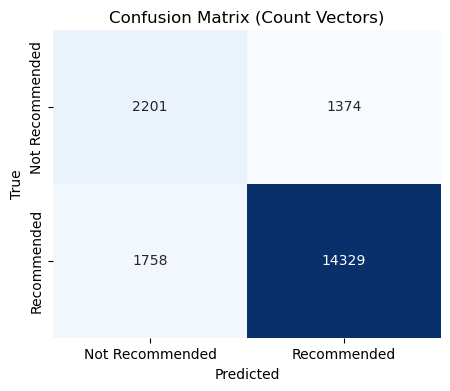


=== Using Unweighted Vectors ===
Average Accuracy: 0.804
Average F1 Score: 0.813

Classification Report (Aggregated):
              precision    recall  f1-score   support

           0      0.469     0.617     0.533      3575
           1      0.909     0.845     0.876     16087

    accuracy                          0.804     19662
   macro avg      0.689     0.731     0.704     19662
weighted avg      0.829     0.804     0.813     19662

Confusion Matrix:
[[ 2207  1368]
 [ 2494 13593]]


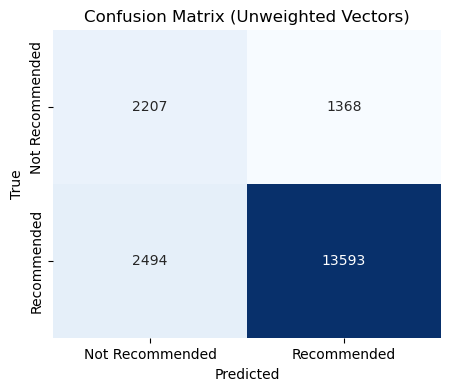


=== Using Weighted Vectors ===
Average Accuracy: 0.807
Average F1 Score: 0.815

Classification Report (Aggregated):
              precision    recall  f1-score   support

           0      0.476     0.592     0.528      3575
           1      0.904     0.855     0.879     16087

    accuracy                          0.807     19662
   macro avg      0.690     0.724     0.704     19662
weighted avg      0.826     0.807     0.815     19662

Confusion Matrix:
[[ 2117  1458]
 [ 2327 13760]]


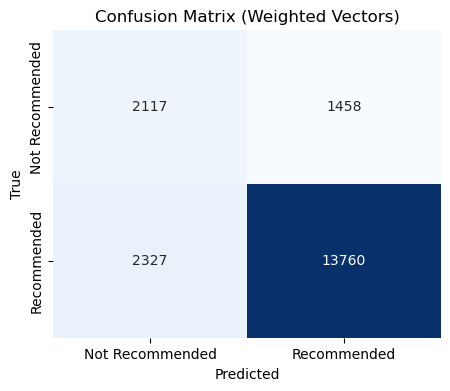

In [530]:
run_model_analysis(title_count_vectors, X_title_unweighted, X_title_weighted, y)

### Title + Review Text

In [531]:
df = pd.read_csv('processed.csv')
# 2/3/4. Tokenizing clothing review

# define tokenizer
tokenizer = RegexpTokenizer(r"[a-zA-Z]+(?:[-'][a-zA-Z]+)?")

df["combined_text"] = (
    df["Title"].fillna("").astype(str) + " " + df["Review Text"].fillna("").astype(str)
)
# Tokenize the review text + lowercasing and removing words with length < 2
df["review_title_tokens"] = (
    df["combined_text"]
      .fillna("") # replace NaN with empty string
      .astype(str)
      .apply(lambda text: [token.lower() for token in tokenizer.tokenize(text) if len(token) > 1])
)

df["review_title_tokens"]

0        [some, major, design, flaws, had, such, high, ...
1        [my, favorite, buy, love, love, love, this, ju...
2        [flattering, shirt, this, shirt, is, very, fla...
3        [not, for, the, very, petite, love, tracy, ree...
4        [cagrcoal, shimmer, fun, aded, this, in, my, b...
                               ...                        
19657    [great, dress, for, many, occasions, was, very...
19658    [wish, it, was, made, of, cotton, it, reminds,...
19659    [cute, but, see, through, this, fit, well, but...
19660    [very, cute, dress, perfect, for, summer, part...
19661    [please, make, more, like, this, one, this, dr...
Name: review_title_tokens, Length: 19662, dtype: object

In [532]:
# --- Apply preprocessing to Title ---
df["review_title_tokens"] = preprocess_data(df["review_title_tokens"])
df["review_title_tokens"]

0        [major, design, flaw, high, hope, wanted, work...
1        [favorite, buy, jumpsuit, fun, flirty, fabulou...
2        [shirt, shirt, due, adjustable, front, tie, le...
3        [petite, tracy, reese, dress, petite, foot, ta...
4        [charcoal, shimmer, fun, add, basket, minute, ...
                               ...                        
19657    [occasion, happy, snag, price, easy, slip, cut...
19658    [made, cotton, reminds, maternity, clothes, st...
19659                 [worked, glad, store, order, online]
19660    [summer, party, bought, wedding, summer, mediu...
19661    [make, lovely, feminine, perfectly, easy, comf...
Name: review_title_tokens, Length: 19662, dtype: object

In [533]:
review_title_unweighted, review_title_weighted = embed_data(df["review_title_tokens"], type='review_title')
review_title_count_vectors = load_vectors("review_title_count_vectors.txt", sparse=True)

In [534]:
X_review_title_unweighted = StandardScaler().fit_transform(review_title_unweighted)
X_review_title_weighted   = StandardScaler().fit_transform(review_title_weighted)


=== Using Count Vectors ===
Average Accuracy: 0.841
Average F1 Score: 0.844

Classification Report (Aggregated):
              precision    recall  f1-score   support

           0      0.556     0.616     0.584      3575
           1      0.913     0.891     0.901     16087

    accuracy                          0.841     19662
   macro avg      0.734     0.753     0.743     19662
weighted avg      0.848     0.841     0.844     19662

Confusion Matrix:
[[ 2201  1374]
 [ 1758 14329]]


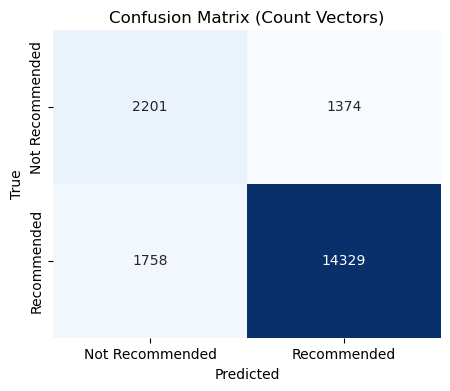


=== Using Unweighted Vectors ===
Average Accuracy: 0.813
Average F1 Score: 0.824

Classification Report (Aggregated):
              precision    recall  f1-score   support

           0      0.490     0.676     0.568      3575
           1      0.921     0.843     0.881     16087

    accuracy                          0.813     19662
   macro avg      0.706     0.760     0.724     19662
weighted avg      0.843     0.813     0.824     19662

Confusion Matrix:
[[ 2418  1157]
 [ 2518 13569]]


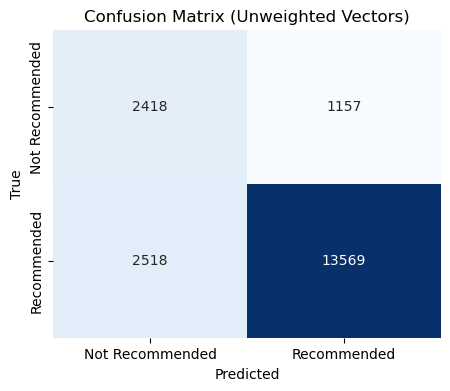


=== Using Weighted Vectors ===
Average Accuracy: 0.809
Average F1 Score: 0.820

Classification Report (Aggregated):
              precision    recall  f1-score   support

           0      0.481     0.662     0.557      3575
           1      0.918     0.841     0.878     16087

    accuracy                          0.809     19662
   macro avg      0.700     0.752     0.718     19662
weighted avg      0.839     0.809     0.820     19662

Confusion Matrix:
[[ 2367  1208]
 [ 2552 13535]]


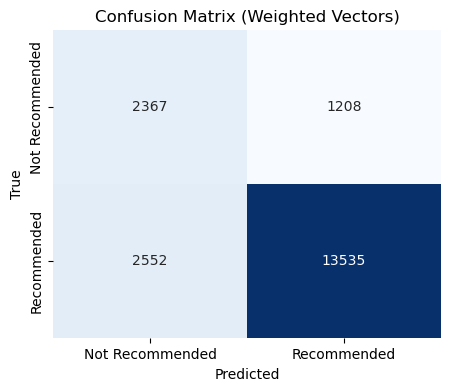

In [535]:
run_model_analysis(title_count_vectors, X_review_title_unweighted, X_review_title_weighted, y)

## Summary
Give a short summary and anything you would like to talk about the assessment tasks here.

## Couple of notes for all code blocks in this notebook
- please provide proper comment on your code
- Please re-start and run all cells to make sure codes are runable and include your output in the submission.   
<span style="color: red"> This markdown block can be removed once the task is completed. </span>